# Análisis Exploratorio de Datos (EDA)
El objetivo de este análisis exploratorio de datos (EDA) es evaluar si los conjuntos de datos train y test presentan una estructura y comportamiento similares.
Para ello, se compararán sus características principales, distribuciones de variables y relaciones entre ellas.

El propósito final es comprobar que ambos datasets siguen la misma distribución, de modo que un modelo entrenado con el conjunto de entrenamiento pueda generalizar correctamente sobre el conjunto de test.

# 1. Carga y comparación de la estructura.

In [1]:
import pandas as pd
import numpy as np

Cargamos los datasets:

In [2]:
train = pd.read_csv("titanic_datasets/processed/train_processed.csv")
test = pd.read_csv("titanic_datasets/processed/test_processed.csv")

Comparamos dimensiones:

In [3]:
train.shape, test.shape

((712, 28), (179, 28))

Comparamos tipos de datos

In [4]:
train.dtypes.equals(test.dtypes)

True

Comparación de columnas:

In [5]:
train.columns.equals(test.columns)

True

Ambos datasets presentan la misma estructura, con idéntico número de variables, mismas columnas y tipos de datos. Por tanto, existe coherencia entre train y test, lo que permite continuar el análisis comparativo y el posterior modelado.

# 2. Comparación de valores nulos

In [6]:
# Valores nulos en train
nulls_train = train.isnull().sum().sum()

# Valores nulos en test
nulls_test = test.isnull().sum().sum()

print(f"Train: {nulls_train} nulos")
print(f"Test: {nulls_test} nulos")

Train: 0 nulos
Test: 0 nulos


No se detectan valores nulos en ninguno de los dos datasets, lo que indica que el preprocesado ha sido aplicado correctamente y de forma consistente en train y test.

# 3. Comparación de distribuciones

Queremos analizar si las variables presentan distribuciones similares en ambos datasets, lo que permitiría asumir que no existe cambio de distribución.

Separamos las variables numéricas y categóricas

In [7]:
import matplotlib.pyplot as plt

# Variables numéricas
num_cols = train.select_dtypes(include=np.number).columns

# Variables categóricas
cat_cols = train.select_dtypes(exclude=np.number).columns

Histogramas comparando la clase:

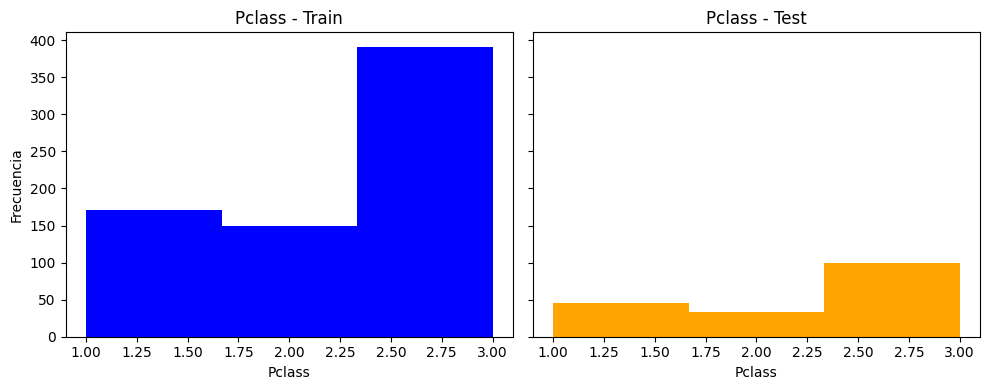

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
axes[0].hist(train["Pclass"], bins=3, color="blue")
axes[0].set_title("Pclass - Train")
axes[0].set_xlabel("Pclass")
axes[0].set_ylabel("Frecuencia")

# Test
axes[1].hist(test["Pclass"], bins=3, color="orange")
axes[1].set_title("Pclass - Test")
axes[1].set_xlabel("Pclass")

plt.tight_layout()
plt.show()

Histogramas comparando la edad:

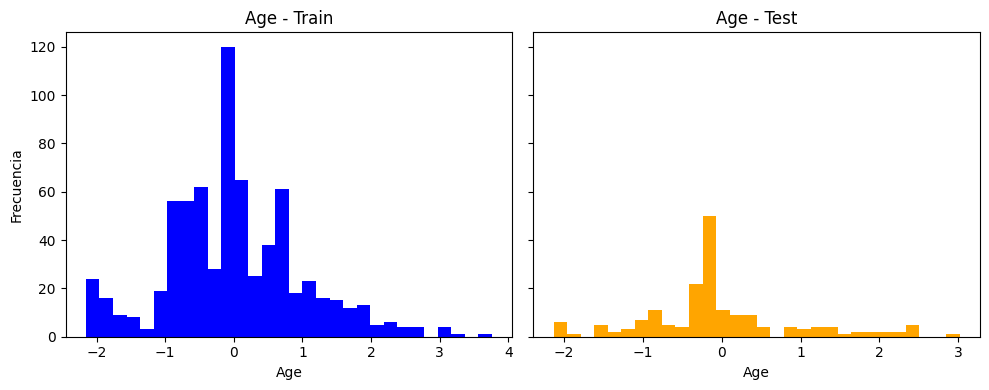

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
axes[0].hist(train["Age"], bins=30, color="blue")
axes[0].set_title("Age - Train")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frecuencia")

# Test
axes[1].hist(test["Age"], bins=30, color="orange")
axes[1].set_title("Age - Test")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

Sex:

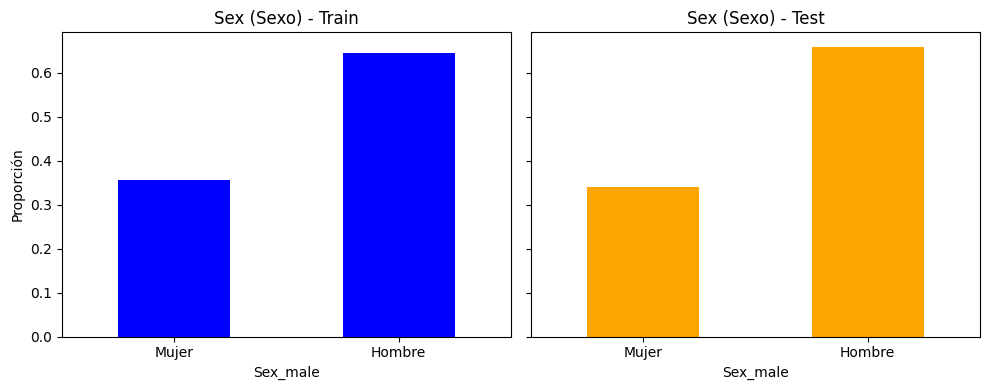

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
train["Sex_male"].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=axes[0], color="blue"
)
axes[0].set_title("Sex (Sexo) - Train")
axes[0].set_xticklabels(["Mujer", "Hombre"], rotation=0)
axes[0].set_ylabel("Proporción")

# Test
test["Sex_male"].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=axes[1], color="orange"
)
axes[1].set_title("Sex (Sexo) - Test")
axes[1].set_xticklabels(["Mujer", "Hombre"], rotation=0)

plt.tight_layout()
plt.show()

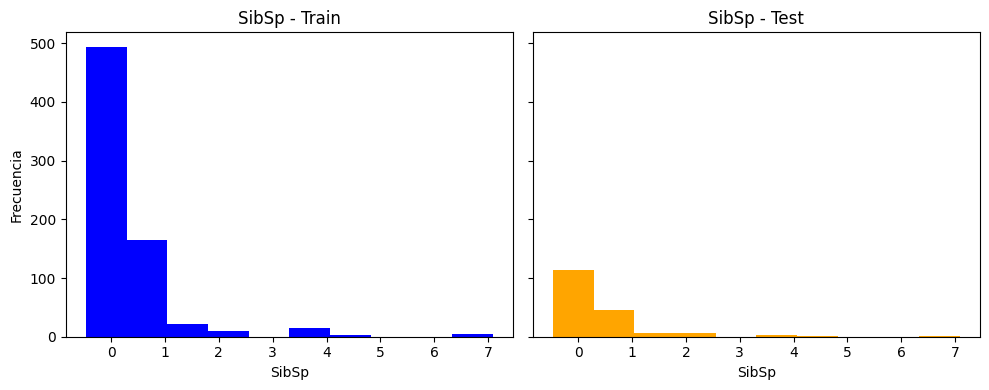

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
axes[0].hist(train["SibSp"], bins=10, color="blue")
axes[0].set_title("SibSp - Train")
axes[0].set_xlabel("SibSp")
axes[0].set_ylabel("Frecuencia")

# Test
axes[1].hist(test["SibSp"], bins=10, color="orange")
axes[1].set_title("SibSp - Test")
axes[1].set_xlabel("SibSp")

plt.tight_layout()
plt.show()

Parch (Padres/Hijos a bordo):

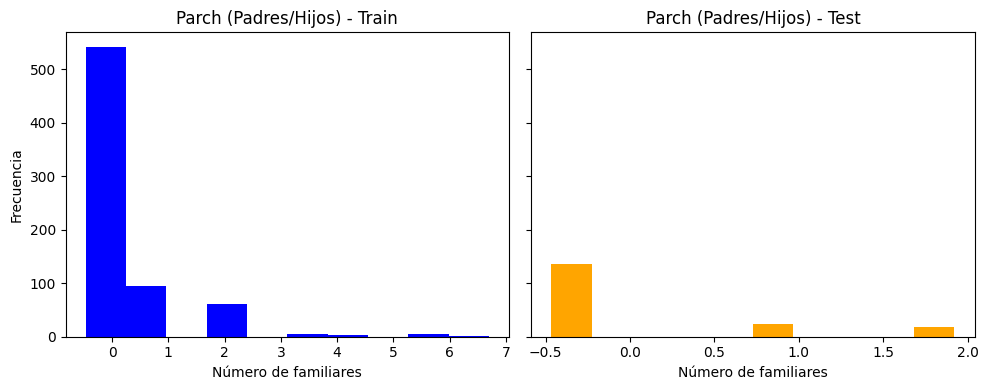

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
axes[0].hist(train["Parch"], bins=10, color="blue")
axes[0].set_title("Parch (Padres/Hijos) - Train")
axes[0].set_xlabel("Número de familiares")
axes[0].set_ylabel("Frecuencia")

# Test
axes[1].hist(test["Parch"], bins=10, color="orange")
axes[1].set_title("Parch (Padres/Hijos) - Test")
axes[1].set_xlabel("Número de familiares")

plt.tight_layout()
plt.show()

Fare (Tarifa pagada):

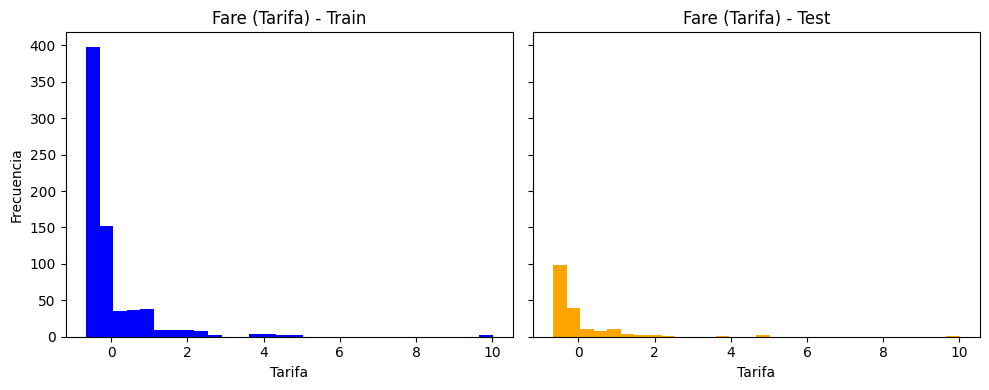

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
axes[0].hist(train["Fare"], bins=30, color="blue")
axes[0].set_title("Fare (Tarifa) - Train")
axes[0].set_xlabel("Tarifa")
axes[0].set_ylabel("Frecuencia")

# Test
axes[1].hist(test["Fare"], bins=30, color="orange")
axes[1].set_title("Fare (Tarifa) - Test")
axes[1].set_xlabel("Tarifa")

plt.tight_layout()
plt.show()

Embarked (Puerto de embarque):

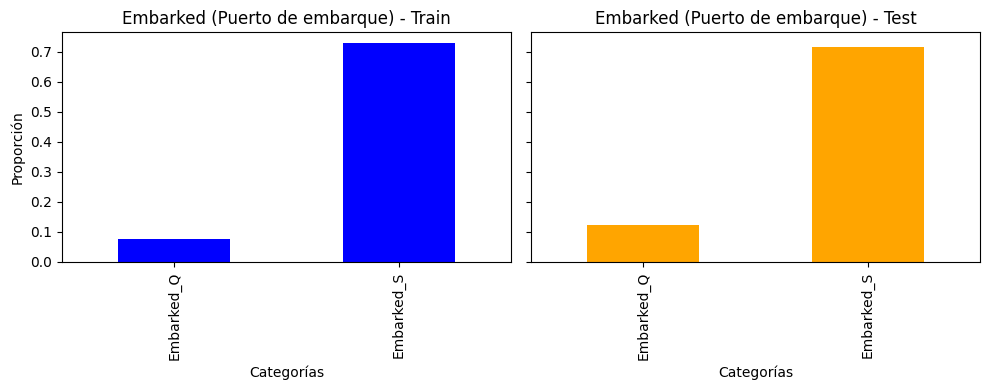

In [14]:
embarked_cols = [col for col in train.columns if "Embarked" in col]

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
train[embarked_cols].mean().plot(
    kind="bar", ax=axes[0], color="blue"
)
axes[0].set_title("Embarked (Puerto de embarque) - Train")
axes[0].set_xlabel("Categorías")
axes[0].set_ylabel("Proporción")

# Test
test[embarked_cols].mean().plot(
    kind="bar", ax=axes[1], color="orange"
)
axes[1].set_title("Embarked (Puerto de embarque) - Test")
axes[1].set_xlabel("Categorías")

plt.tight_layout()
plt.show()

## 3.9 Detección de outliers

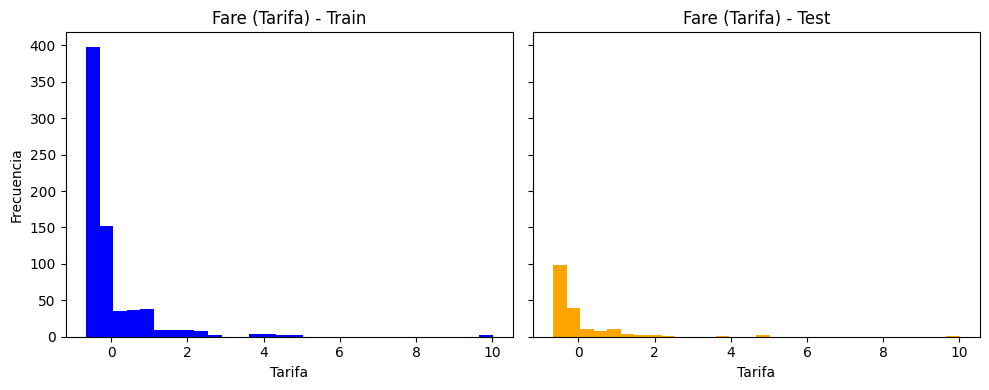

In [ ]:

# Detección de outliers usando IQR y z-score sobre los datos estandarizados.
# Dado que los datos ya están normalizados con StandardScaler,
# un valor con |z| > 3 indica más de 3 desviaciones estándar respecto a la media.

num_cols_out = ["Age", "Fare", "SibSp", "Parch", "FamilySize", "TicketGroup"]

resultados = []
for col in num_cols_out:
    # z-score (sobre datos ya estandarizados, |z| > 3 es el umbral clásico)
    n_zscore = (train[col].abs() > 3).sum()

    # IQR
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    n_iqr = ((train[col] < q1 - 1.5 * iqr) | (train[col] > q3 + 1.5 * iqr)).sum()

    resultados.append({
        "Variable": col,
        "Outliers |z|>3": n_zscore,
        "% total (z)": round(n_zscore / len(train) * 100, 2),
        "Outliers IQR": n_iqr,
        "% total (IQR)": round(n_iqr / len(train) * 100, 2),
    })

outliers_df = pd.DataFrame(resultados)
print("Detección de outliers (datos estandarizados):")
print(outliers_df.to_string(index=False))

# Boxplots
fig, axes = plt.subplots(1, len(num_cols_out), figsize=(18, 4))
for ax, col in zip(axes, num_cols_out):
    ax.boxplot(train[col].dropna(), vert=True, whis=1.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("z-score")

plt.suptitle("Boxplots de variables numéricas (datos estandarizados)", fontsize=12)
plt.tight_layout()
plt.show()


`Fare` es la variable con mayor número de outliers: algunos pasajeros pagaron tarifas muy por encima de la media (suites de primera clase). Los demás variables numéricas tienen pocos o ningún outlier relevante.

**Decisión**: se decide no truncar los outliers de `Fare`. La red neuronal es menos sensible a valores extremos que un modelo lineal, gracias a las activaciones no lineales y a que los datos ya están normalizados. Además, estos outliers corresponden a pasajeros reales de alto poder adquisitivo y eliminarlos haría perder información sobre la clase socioeconómica, que es una de las variables más correlacionadas con la supervivencia.

Deck (Cubierta del barco):

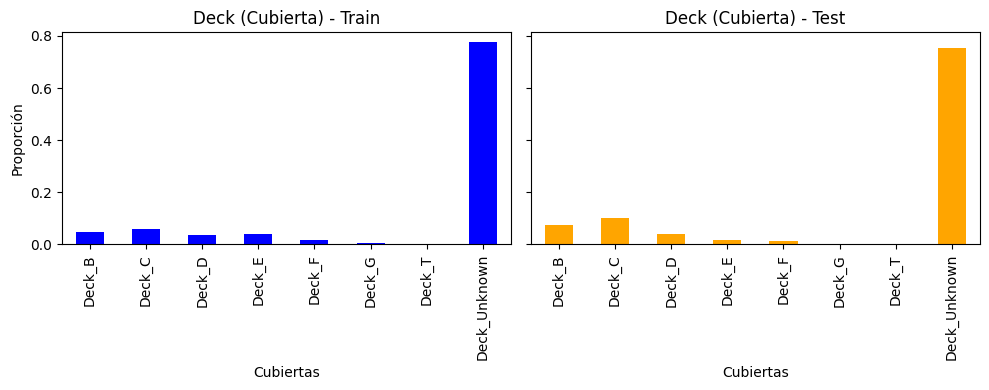

In [16]:
deck_cols = [col for col in train.columns if "Deck" in col]

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

# Train
train[deck_cols].mean().plot(
    kind="bar", ax=axes[0], color="blue"
)
axes[0].set_title("Deck (Cubierta) - Train")
axes[0].set_xlabel("Cubiertas")
axes[0].set_ylabel("Proporción")

# Test
test[deck_cols].mean().plot(
    kind="bar", ax=axes[1], color="orange"
)
axes[1].set_title("Deck (Cubierta) - Test")
axes[1].set_xlabel("Cubiertas")

plt.tight_layout()
plt.show()

En conjunto, tanto las variables numéricas como categóricas presentan distribuciones muy similares en los conjuntos train y test. No se observan diferencias significativas ni en la forma, ni en los rangos, ni en las proporciones de las variables analizadas.

En consecuencia, el modelo entrenado con el conjunto de entrenamiento podrá generalizar de manera adecuada sobre el conjunto de test.

# 4. Análisis respecto a la variable objetivo (Survived)

## 4.1. Variables categóricas vs Survived

In [17]:
train.groupby("Sex_male")["Survived"].mean()

Sex_male
0    0.743083
1    0.185185
Name: Survived, dtype: float64

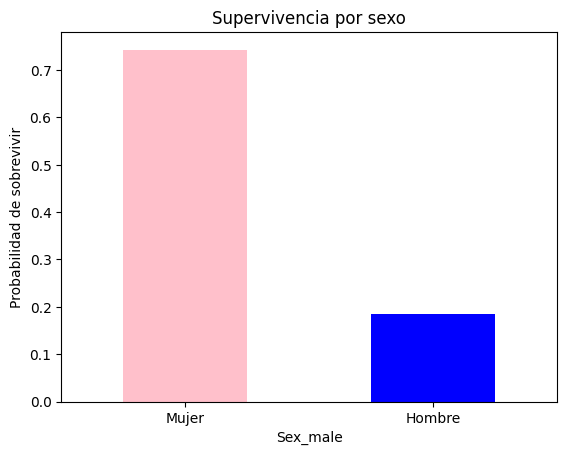

In [19]:
train.groupby("Sex_male")["Survived"].mean().plot(kind="bar", color=["pink", "blue"])
plt.xticks([0,1], ["Mujer", "Hombre"], rotation=0)
plt.title("Supervivencia por sexo")
plt.ylabel("Probabilidad de sobrevivir")
plt.show()

Existe una diferencia clara en la supervivencia según el sexo, siendo significativamente mayor en mujeres que en hombres.

## 4.2. Pclass vs Survived

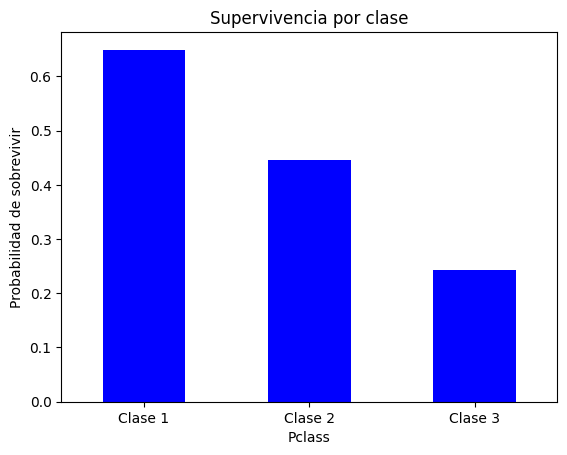

In [21]:
train.groupby("Pclass")["Survived"].mean().plot(kind="bar", color="blue")
plt.title("Supervivencia por clase")
plt.xticks([0,1,2], ["Clase 1", "Clase 2", "Clase 3"], rotation=0)
plt.ylabel("Probabilidad de sobrevivir")
plt.show()

La probabilidad de supervivencia es mayor en clases superiores, disminuyendo progresivamente en clases más bajas.

## 4.3 Age vs Survived

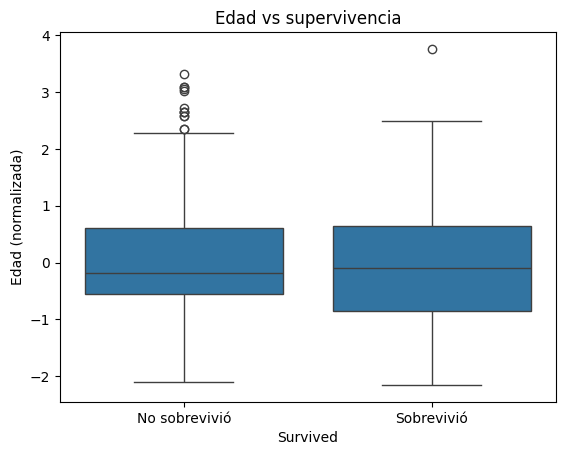

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=train["Survived"], y=train["Age"])

plt.xticks([0,1], ["No sobrevivió", "Sobrevivió"])
plt.title("Edad vs supervivencia")
plt.ylabel("Edad (normalizada)")

plt.show()

No se observan diferencias claras en la edad entre quienes sobrevivieron y quienes no, por lo que no parece una variable determinante por sí sola.

## 4.4. Fare vs Survived

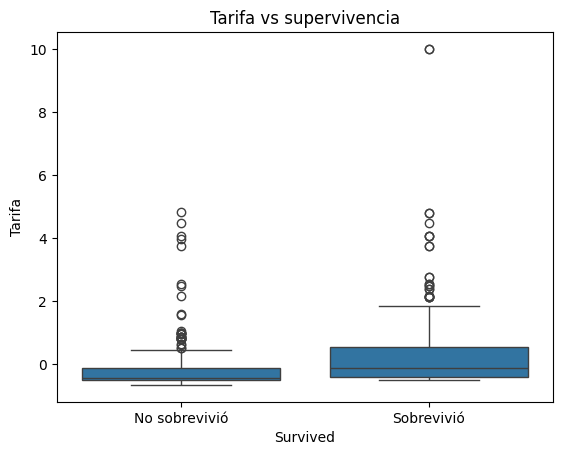

In [28]:

sns.boxplot(x=train["Survived"], y=train["Fare"])

plt.xticks([0,1], ["No sobrevivió", "Sobrevivió"])
plt.title("Tarifa vs supervivencia")
plt.ylabel("Tarifa")

plt.show()

Los pasajeros que pagaron tarifas más altas presentan mayor probabilidad de supervivencia, lo que sugiere relación con la clase socioeconómica.

## 4.5. Family (SibSp + Parch)

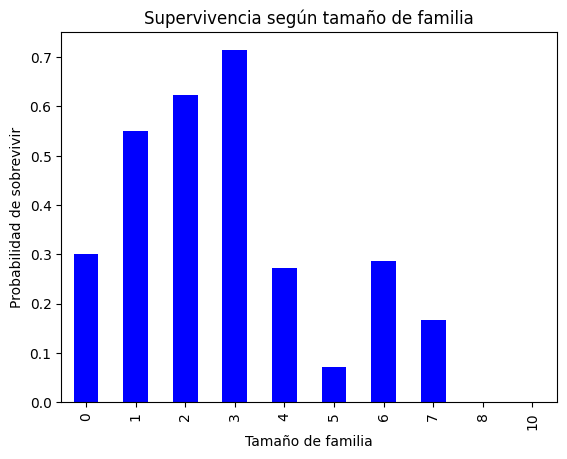

In [31]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
train["FamilySize"] = train["FamilySize"].round(0).astype(int)

family_survival = train.groupby("FamilySize")["Survived"].mean()

family_survival.plot(kind="bar", color="blue")

plt.title("Supervivencia según tamaño de familia")
plt.xlabel("Tamaño de familia")
plt.ylabel("Probabilidad de sobrevivir")

plt.show()

La supervivencia es mayor en familias pequeñas, mientras que disminuye en pasajeros que viajan solos o en familias numerosas.

## 4.6. ¿Qué variables influyen más en la supuervivencia?

In [32]:
corr_survived = train.corr()["Survived"].sort_values(ascending=False)
corr_survived

Survived                1.000000
Title_Mrs               0.347373
Title_Miss              0.336459
FamilyCategory_Small    0.294570
Fare                    0.275499
Deck_D                  0.169875
Deck_B                  0.162058
Deck_E                  0.159005
Deck_C                  0.152263
Deck_F                  0.088586
Parch                   0.084178
AgeGroup_Teenager       0.069536
TicketGroup             0.032767
Embarked_Q              0.031501
FamilySize              0.022927
Deck_G                  0.018021
Title_Rare              0.001809
SibSp                  -0.026115
Deck_T                 -0.029574
AgeGroup_Elderly       -0.061096
Age                    -0.074464
AgeGroup_Adult         -0.113786
FamilyCategory_Large   -0.126287
Embarked_S             -0.179163
Pclass                 -0.348007
Deck_Unknown           -0.350535
Sex_male               -0.549171
Title_Mr               -0.555587
Name: Survived, dtype: float64

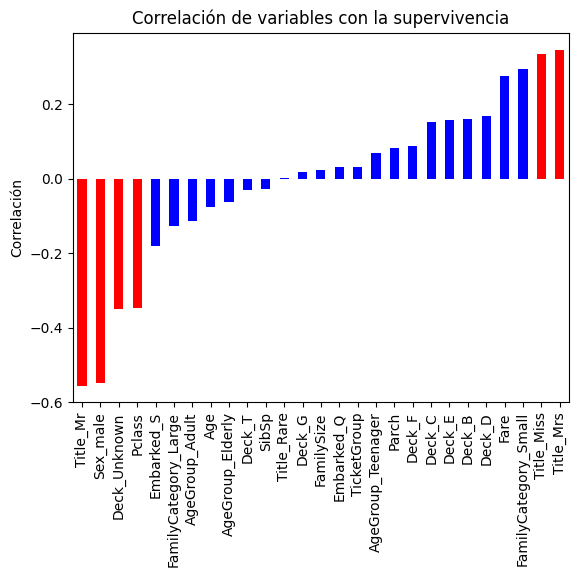

In [35]:
corr_survived = train.corr()["Survived"].drop("Survived").sort_values()

colors = ["red" if abs(val) > 0.3 else "blue" for val in corr_survived]

corr_survived.plot(kind="bar", color=colors)

plt.title("Correlación de variables con la supervivencia")
plt.ylabel("Correlación")

plt.show()

El gráfico muestra la correlación entre cada variable y la variable objetivo (Survived), permitiendo identificar qué factores influyen más en la probabilidad de supervivencia.

Se observa que las variables con mayor correlación son el sexo (Sex_male), la clase (Pclass) y las variables derivadas del título (Title_Mr, Title_Mrs, Title_Miss), así como la tarifa (Fare).

En particular, ser mujer o pertenecer a clases más altas se asocia con una mayor probabilidad de supervivencia, mientras que ser hombre o viajar en clases bajas la reduce.

En general, el gráfico permite identificar las variables más relevantes para el modelo, destacando aquellas con mayor valor absoluto de correlación como las más influyentes en la predicción de la supervivencia.

# 5. Matriz de correlación

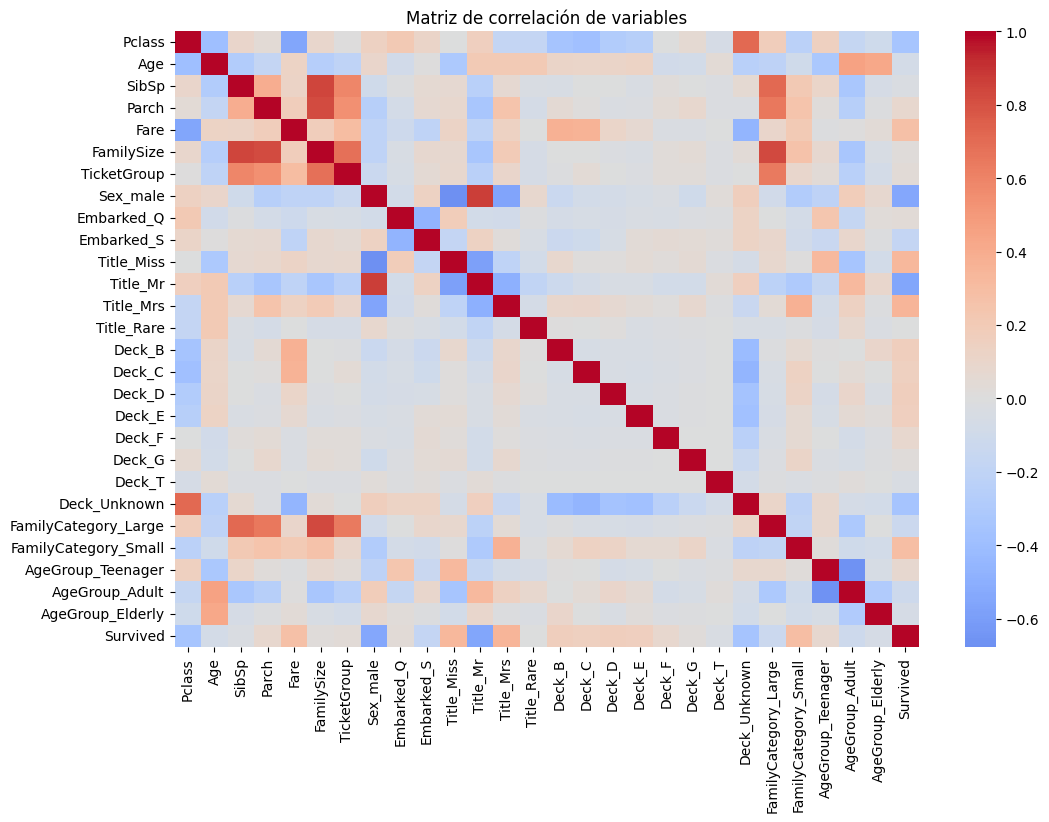

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train.corr(),
    cmap="coolwarm",
    annot=False,
    center=0
)

plt.title("Matriz de correlación de variables")
plt.show()

La matriz de correlación permite analizar la relación entre todas las variables del dataset. En particular, resulta útil para identificar aquellas variables que presentan mayor relación con la variable objetivo (Survived), así como detectar posibles redundancias entre variables explicativas.

Se observa que variables como el sexo, la clase y la tarifa presentan correlaciones relevantes con la supervivencia. Asimismo, algunas variables muestran alta correlación entre sí, lo que indica posible redundancia en la información que aportan al modelo.